# Notebook Tuning BERTopic vs LDA

Notebook ini dipakai untuk tuning BERTopic dan LDA dengan konfigurasi yang selaras dengan form Laravel, memakai komponen FastAPI agar hasil tetap konsisten.

Alur utama:
1. Preprocessing
2. Tuning BERTopic
3. Tuning LDA
4. Komparasi model
5. Retrain best model
6. Visualisasi dan DTA

Artefak tiap tahap disimpan ke folder run dalam format CSV/JSON.

In [7]:
import itertools
import json
import math
import random
import sys
import time
import os
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from wordcloud import WordCloud
except Exception:
    WordCloud = None

from IPython.display import display

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Konfigurasi path lokal.
CWD = Path.cwd()

candidate_fastapi_roots = [
    CWD,
    CWD / "fastapi",
    CWD.parent,
    CWD.parent / "fastapi",
]

FASTAPI_ROOT = None
for candidate in candidate_fastapi_roots:
    if (candidate / "app").exists():
        FASTAPI_ROOT = candidate.resolve()
        break

if FASTAPI_ROOT is None:
    raise FileNotFoundError(
        "Folder FastAPI tidak ditemukan. Jalankan notebook dari root repo atau folder fastapi."
    )

DATA_RAW_DIR = FASTAPI_ROOT / "data" / "raw"
if not DATA_RAW_DIR.exists():
    raise FileNotFoundError(f"Folder data raw tidak ditemukan: {DATA_RAW_DIR}")

raw_csv_candidates = sorted(DATA_RAW_DIR.glob("*.csv"))
if not raw_csv_candidates:
    raise FileNotFoundError(f"Tidak ada file CSV pada folder: {DATA_RAW_DIR}")

# Pastikan import app.* terbaca.
if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

try:
    from app.ml.bertopic_trainer import BERTopicTrainer
    from app.ml.evaluator import TopicEvaluator
    from app.ml.lda_trainer import LDATrainer
    from app.models.schemas import (
        BERTopicHyperparameters,
        HDBSCANHyperparameters,
        LDAHyperparameters,
        UMAPHyperparameters,
    )
    from app.services.preprocessing import TextPreprocessor
except ImportError as exc:
    raise ImportError(
        f"Gagal import module FastAPI dari {FASTAPI_ROOT}. Pastikan dependency sudah terpasang."
    ) from exc

RUN_TS = datetime.now().strftime("%Y%m%d-%H%M%S")
ARTIFACT_ROOT = FASTAPI_ROOT / "data" / "results" / "notebook_tuning_web_form"
RUN_DIR = ARTIFACT_ROOT / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("CWD:", CWD)
print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("DATA_RAW_DIR:", DATA_RAW_DIR)
print("Raw CSV:", [p.name for p in raw_csv_candidates])
print("RUN_DIR:", RUN_DIR)
print("WordCloud available:", WordCloud is not None)

CWD: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/scripts
FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
DATA_RAW_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw
Raw CSV: ['raw_data.csv']
RUN_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001
WordCloud available: True


## 1) Konfigurasi Parameter

Gunakan `WEB_FORM_*_BASE` agar nilainya konsisten dengan form Laravel.

Catatan:
- `*_TUNING_SPACE` bisa dibangun ulang setelah profiling data.
- BERTopic menyertakan `nr_topics = auto` dan nilai >= 8.
- LDA memakai kombinasi kecil-besar yang masih realistis untuk ukuran data.

In [8]:
# Base params selaras form Laravel.
WEB_FORM_BERTOPIC_BASE = {
    "embedding_model": "denaya/indoSBERT-large",
    "min_topic_size": 10,
    "nr_topics": 8,
    "top_n_words": 15,
    "n_gram_range": [1, 2],
    "vectorizer_min_df": 2,
    "vectorizer_max_df": 0.95,
    "vectorizer_token_pattern": r"(?u)\b\w{3,}\b",
    "vectorizer_fallback_min_df": 1,
    "vectorizer_fallback_max_df": 1.0,
    "coherence_type": "c_v",
    "coherence_tokenization": "vectorizer",
    "coherence_dict_no_below": 3,
    "coherence_dict_no_above": 0.95,
    "reduce_outliers": True,
    "reduce_outliers_threshold_ctfidf": 0.1,
    "reduce_outliers_use_distributions": True,
    "reduce_outliers_threshold_distributions": 0.05,
    "use_mmr_representation": True,
    "mmr_diversity": 0.3,
    "embedding_batch_size": 16,
    "seed": 42,
    "umap_params": {
        "n_neighbors": 40,
        "n_components": 5,
        "min_dist": 0.0,
        "metric": "cosine",
        "random_state": 42,
    },
    "hdbscan_params": {
        "min_cluster_size": 8,
        "min_samples": 1,
        "metric": "euclidean",
        "cluster_selection_method": "eom",
    },
}

WEB_FORM_LDA_BASE = {
    "num_topics": 12,
    "passes": 20,
    "iterations": 300,
    "chunksize": 100,
    "random_state": 42,
    "alpha": "asymmetric",
    "eta": None,
    "no_below": 2,
    "no_above": 0.95,
}

# Rebuild tuning space setelah profiling data.
AUTO_BUILD_TUNING_SPACE_FROM_DATA = True

# Evaluasi loop: CV + TD. DTA di tahap final.
RUN_DTA_IN_TUNING_LOOP = False
RUN_TEMPORAL_DIST_IN_LDA_LOOP = False

# Ambang minimum jumlah topik.
MIN_TARGET_TOPICS = 8
TOPIC_SHORTFALL_PENALTY = 0.20

# Placeholder awal (bisa dioverride otomatis).
BERTOPIC_TUNING_SPACE = {
    "min_topic_size": [6, 8, 10, 12],
    "nr_topics": ["auto", 8, 10, 12, 14],
    "top_n_words": [15, 20],
    "n_gram_range": [(1, 1), (1, 2)],
    "umap_n_neighbors": [15, 30, 45],
    "umap_n_components": [5, 8],
    "umap_metric": ["cosine"],
    "hdbscan_min_cluster_size": [6, 8, 10, 12],
    "hdbscan_min_samples": [1, 2],
    "hdbscan_metric": ["euclidean"],
}

LDA_TUNING_SPACE = {
    "num_topics": [8, 10, 12, 14],
    "passes": [15, 25],
    "iterations": [200, 300],
    "chunksize": [100, 150],
    "random_state": [42],
    "alpha": ["asymmetric", "symmetric"],
    "eta": [None, "symmetric"],
    "no_below": [2, 3],
    "no_above": [0.90, 0.95],
}

# Batasi jumlah skenario sampling.
MAX_BERTOPIC_SCENARIOS = 24
MAX_LDA_SCENARIOS = 24
SCENARIO_SEED = 42

print("BERTopic base params loaded")
print("LDA base params loaded")
print("AUTO_BUILD_TUNING_SPACE_FROM_DATA:", AUTO_BUILD_TUNING_SPACE_FROM_DATA)
print("RUN_DTA_IN_TUNING_LOOP:", RUN_DTA_IN_TUNING_LOOP)
print("RUN_TEMPORAL_DIST_IN_LDA_LOOP:", RUN_TEMPORAL_DIST_IN_LDA_LOOP)
print("MIN_TARGET_TOPICS:", MIN_TARGET_TOPICS)

BERTopic base params loaded
LDA base params loaded
AUTO_BUILD_TUNING_SPACE_FROM_DATA: True
RUN_DTA_IN_TUNING_LOOP: False
RUN_TEMPORAL_DIST_IN_LDA_LOOP: False
MIN_TARGET_TOPICS: 8


## 2) Preprocessing + Export CSV

Pipeline mengikuti FastAPI: drop null/dedup abstract, preprocessing teks, lalu ekspor hasil per tahap.

In [9]:
try:
    from app.services.preprocessing import TextPreprocessor
except (ImportError, ModuleNotFoundError, NameError):
    print("Menggunakan mock TextPreprocessor karena module asli tidak ditemukan.")
    class TextPreprocessor:
        def __init__(self, **kwargs):
            pass
        def preprocess_dataframe(self, df, text_column, **kwargs):
            # Mock preprocessing sederhana.
            df = df.copy()
            df['cleaned_text'] = df[text_column].astype(str).str.lower().str.replace(r'[^\w\s]', '', regex=True)
            df['processed_text'] = df['cleaned_text']
            df['combined_text'] = df['cleaned_text']
            return df

preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    min_word_length=3,
    language="indonesian",
)

def _normalize_dataset_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    normalized_map = {}
    for col in df.columns:
        normalized = str(col).strip().lower().replace("%", "pct")
        normalized = "".join(ch if ch.isalnum() else "_" for ch in normalized)
        while "__" in normalized: normalized = normalized.replace("__", "_")
        normalized_map[col] = normalized.strip("_") or "col"
    df = df.rename(columns=normalized_map)
    aliases = {"id": ["id", "skripsi_id"], "title": ["title", "judul"], "author": ["author", "penulis"], "year": ["year", "tahun"], "abstract": ["abstract", "abstrak"], "conclusion": ["conclusion", "kesimpulan"]}
    for target, cols in aliases.items():
        if target in df.columns: continue
        existing = [c for c in cols if c in df.columns]
        if existing: df[target] = df[existing[0]]
    if "id" not in df.columns: df["id"] = range(1, len(df) + 1)
    for text_col in ["title", "abstract", "conclusion"]:
        if text_col in df.columns:
            df[text_col] = df[text_col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    return df

def _pick_raw_csv_path(raw_dir: Path) -> Path:
    preferred = raw_dir / "raw_data.csv"
    if preferred.exists():
        return preferred

    csv_candidates = sorted(raw_dir.glob("*.csv"))
    if not csv_candidates:
        raise FileNotFoundError(f"Tidak ada file CSV pada folder: {raw_dir}")
    return csv_candidates[0]

def _load_raw_from_csv_only() -> tuple[pd.DataFrame, str]:
    raw_csv_path = _pick_raw_csv_path(DATA_RAW_DIR)
    print(f"Menggunakan data raw: {raw_csv_path}")
    df = pd.read_csv(raw_csv_path)
    return _normalize_dataset_columns(df), f"csv:{raw_csv_path}"

raw_df, data_source = _load_raw_from_csv_only()
if "abstract" not in raw_df.columns: raise ValueError("Kolom abstract tidak ditemukan.")

stage_df = raw_df.copy()
stage_df = stage_df.dropna(subset=["abstract"]).reset_index(drop=True)
stage_df = stage_df.drop_duplicates(subset=["abstract"]).reset_index(drop=True)

preprocessed_df = preprocessor.preprocess_dataframe(stage_df, text_column="abstract")

display(preprocessed_df.head())
print("Preprocessing selesai.")

2026-04-19 19:10:01.262 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-19 19:10:01.263 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...


Menggunakan data raw: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv


2026-04-19 19:10:01.394 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-19 19:10:01.519 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-19 19:18:26.361 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-19 19:18:26.375 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-19 19:18:26.382 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


,id,judul,penulis,tahun,tipe,id_code,kata_kunci,subjects,divisions,abstrak,kesimpulan,sumber_kesimpulan,url,tanggal_deposit,tanggal_modifikasi,title,author,year,abstract,conclusion,combined_text,cleaned_text,processed_text
0,1,"Perbandingan Metode Grid Search, Random Search...","NUGRAHA, Ady Septian",2026,Thesis (Skripsi),NaN,"Analisis Sentimen, Coretax, BERT, Optimasi Hyp...",T > T36 Taxation,Fakultas Teknik > S1 Teknik Informatika,Layanan perpajakan digital Website Coretax yan...,Berdasarkan hasil penelitian yang telah dilaku...,Bab V (PDF),https://repository.unsoed.ac.id/40457,25 Mar 2026 07:28,25 Mar 2026 07:28,"Perbandingan Metode Grid Search, Random Search...","NUGRAHA, Ady Septian",2026,Layanan perpajakan digital Website Coretax yan...,Berdasarkan hasil penelitian yang telah dilaku...,"Perbandingan Metode Grid Search, Random Search...","perbandingan metode grid search, random search...",banding grid search random search bayesian opt...
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,"MAHAPUTRI, Kintan Kinasih Maha",2026,Thesis (Skripsi),NaN,"Produktivitas Pertanian, Klasterisasi, K-Medoi...",A > A137 Agricultural innovations,Fakultas Teknik > S1 Teknik Informatika,Produktivitas pertanian padi merupakan aspek p...,"Berdasarkan hasil penelitian, perancangan, dan...",Bab V (PDF),https://repository.unsoed.ac.id/40439,10 Mar 2026 02:52,10 Mar 2026 02:52,Klasterisasi Produktivitas Pertanian di Kabupa...,"MAHAPUTRI, Kintan Kinasih Maha",2026,Produktivitas pertanian padi merupakan aspek p...,"Berdasarkan hasil penelitian, perancangan, dan...",Klasterisasi Produktivitas Pertanian di Kabupa...,klasterisasi produktivitas pertanian di kabupa...,klasterisasi produktivitas tani kabupaten bata...
2,3,Implementasi Algoritma Holt-Winters Exponentia...,"NISA, Ukhti",2026,Thesis (Skripsi),NaN,"Holt-Winters, Exponential Smoothing, Prediksi,...",C > C1009 Cultural tourism,Fakultas Teknik > S1 Teknik Informatika,Kunjungan wisatawan pada destinasi wisata cend...,Berdasarkan hasil penelitian mengenai implemen...,Bab V (PDF),https://repository.unsoed.ac.id/40438,10 Mar 2026 02:26,10 Mar 2026 02:26,Implementasi Algoritma Holt-Winters Exponentia...,"NISA, Ukhti",2026,Kunjungan wisatawan pada destinasi wisata cend...,Berdasarkan hasil penelitian mengenai implemen...,Implementasi Algoritma Holt-Winters Exponentia...,implementasi algoritma holt-winters exponentia...,implementasi algoritma holt winters exponentia...
3,4,Pengembangan Aplikasi Text Mining untuk Mengek...,"BIMANTORO, Haryo",2026,Thesis (Skripsi),NaN,"Berita Online, Ekstraksi Informasi, Text Minin...",D > D18 Data processing Information systems,Fakultas Teknik > S1 Teknik Informatika,Kebiasaan masyarakat Indonesia yang cenderung ...,"Berdasarkan hasil penelitian, pengembangan apl...",Bab V (PDF),https://repository.unsoed.ac.id/40391,03 Mar 2026 01:45,03 Mar 2026 01:45,Pengembangan Aplikasi Text Mining untuk Mengek...,"BIMANTORO, Haryo",2026,Kebiasaan masyarakat Indonesia yang cenderung ...,"Berdasarkan hasil penelitian, pengembangan apl...",Pengembangan Aplikasi Text Mining untuk Mengek...,pengembangan aplikasi text mining untuk mengek...,kembang aplikasi text mining ekstraksi informa...
4,5,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,"AZ ZUHY, Jehian Athaya Tsani",2026,Thesis (Skripsi),NaN,"Ketahanan Pangan, LSTM, Machine Learning, Nera...",M > M1 Machine design,Fakultas Teknik > S1 Teknik Informatika,Ketahanan pangan merupakan isu kritis bagi Ind...,"Berdasarkan hasil penelitian dengan judul ""Imp...",Bab V (PDF),https://repository.unsoed.ac.id/40116,24 Feb 2026 07:55,24 Feb 2026 07:55,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,"AZ ZUHY, Jehian Athaya Tsani",2026,Ketahanan pangan merupakan isu kritis bagi Ind...,"Berdasarkan hasil penelitian dengan judul ""Imp...",Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,implementasi lstm untuk prediksi konsumsi kalo...,implementasi lstm prediksi konsumsi kalori har...


Preprocessing selesai.


In [10]:
from pathlib import Path

print("Mode local aktif.")
print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("DATA_RAW_DIR:", DATA_RAW_DIR)

raw_csv_files = sorted(DATA_RAW_DIR.glob("*.csv"))
if not raw_csv_files:
    raise FileNotFoundError(f"Tidak ada file CSV pada folder: {DATA_RAW_DIR}")

print("Daftar CSV pada data/raw:")
for path in raw_csv_files:
    print("-", path.name)

Mode local aktif.
FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
DATA_RAW_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw
Daftar CSV pada data/raw:
- raw_data.csv


### Catatan Path Lokal

- Data: `<FASTAPI_ROOT>/data/raw/` (contoh: `fastapi/data/raw/raw_data.csv`)
- Kode FastAPI: `<FASTAPI_ROOT>/app/`

Notebook otomatis memilih CSV dari folder `data/raw`.

In [11]:
def _to_token_array(text):
    if pd.isna(text):
        return []
    return [token for token in str(text).split() if token]

# Gunakan before_after_df jika tersedia; fallback ke preprocessed_df.
before_after_candidate = globals().get("before_after_df")
if isinstance(before_after_candidate, pd.DataFrame) and not before_after_candidate.empty:
    token_array_table_df = before_after_candidate.copy()
else:
    if "preprocessed_df" not in globals() or not isinstance(preprocessed_df, pd.DataFrame):
        raise NameError("before_after_df dan preprocessed_df tidak tersedia. Jalankan Cell 6 dulu.")
    token_array_table_df = preprocessed_df.copy()

for col in ["id", "title", "year", "cleaned_text", "processed_text"]:
    if col not in token_array_table_df.columns:
        if col == "id":
            token_array_table_df[col] = np.arange(1, len(token_array_table_df) + 1)
        elif col == "year":
            token_array_table_df[col] = np.nan
        else:
            token_array_table_df[col] = ""

token_array_table_df["token_array - input bertopic"] = token_array_table_df["cleaned_text"].apply(_to_token_array)
token_array_table_df["token_array - input lda"] = token_array_table_df["processed_text"].apply(_to_token_array)
token_array_table_df["jumlah token - input bertopic"] = token_array_table_df["token_array - input bertopic"].apply(len)
token_array_table_df["jumlah token - input lda"] = token_array_table_df["token_array - input lda"].apply(len)

display_columns = [
    col
    for col in [
        "id",
        "title",
        "year",
        "token_array - input bertopic",
        "token_array - input lda",
        "jumlah token - input bertopic",
        "jumlah token - input lda",
    ]
    if col in token_array_table_df.columns
]

print("Preview token array input BERTopic dan LDA:")
display(token_array_table_df[display_columns].head(5))

# Simpan versi CSV; array diserialisasi ke JSON string.
token_array_export_df = token_array_table_df[display_columns].copy()
if "token_array - input bertopic" in token_array_export_df.columns:
    token_array_export_df["token_array - input bertopic"] = token_array_export_df["token_array - input bertopic"].apply(
        lambda values: json.dumps(values, ensure_ascii=False)
    )
if "token_array - input lda" in token_array_export_df.columns:
    token_array_export_df["token_array - input lda"] = token_array_export_df["token_array - input lda"].apply(
        lambda values: json.dumps(values, ensure_ascii=False)
    )

token_array_table_path = RUN_DIR / "preprocess_step3_token_array_input_bertopic_lda.csv"
token_array_export_df.to_csv(token_array_table_path, index=False)
print("Token array table saved:", token_array_table_path)

Preview token array input BERTopic dan LDA:


,id,title,year,token_array - input bertopic,token_array - input lda,jumlah token - input bertopic,jumlah token - input lda
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,"[perbandingan, metode, grid, search,, random, ...","[banding, grid, search, random, search, bayesi...",428,230
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,"[klasterisasi, produktivitas, pertanian, di, k...","[klasterisasi, produktivitas, tani, kabupaten,...",537,306
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,"[implementasi, algoritma, holt-winters, expone...","[implementasi, algoritma, holt, winters, expon...",367,215
3,4,Pengembangan Aplikasi Text Mining untuk Mengek...,2026,"[pengembangan, aplikasi, text, mining, untuk, ...","[kembang, aplikasi, text, mining, ekstraksi, i...",254,152
4,5,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,2026,"[implementasi, lstm, untuk, prediksi, konsumsi...","[implementasi, lstm, prediksi, konsumsi, kalor...",430,270


Token array table saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001/preprocess_step3_token_array_input_bertopic_lda.csv


## 3) Loop Tuning BERTopic dan LDA

- BERTopic menghitung embedding sekali lalu reuse.
- LDA dilatih per skenario.
- DTA dijalankan di tahap akhir.
- Hasil loop diekspor ke CSV.

In [12]:
def build_combinations(space_dict):
    keys = list(space_dict.keys())
    value_lists = []
    for key in keys:
        value = space_dict[key]
        if isinstance(value, list):
            value_lists.append(value)
        else:
            value_lists.append([value])
    return [dict(zip(keys, values)) for values in itertools.product(*value_lists)]


def sample_combinations(combos, max_items, seed):
    if max_items is None or len(combos) <= max_items:
        return combos
    rng = random.Random(seed)
    return rng.sample(combos, k=max_items)


def normalize_nr_topics(value):
    if value is None:
        return None
    text = str(value).strip().lower()
    if text in {"", "none", "null"}:
        return None
    if text == "auto":
        return "auto"
    return max(8, int(float(text)))


def apply_topic_floor_penalty(score, num_topics, min_topics=8, penalty=0.20):
    base_score = float(score or 0.0)
    if num_topics is None:
        return base_score, False
    try:
        topic_count = int(num_topics)
    except (TypeError, ValueError):
        return base_score, False

    if topic_count >= int(min_topics):
        return base_score, False

    shortfall = int(min_topics) - topic_count
    multiplier = max(0.0, 1.0 - float(penalty) * shortfall)
    return base_score * multiplier, True


def make_bertopic_params(combo):
    ngram = combo["n_gram_range"]
    if not isinstance(ngram, (list, tuple)) or len(ngram) != 2:
        raise ValueError(f"Invalid n_gram_range: {ngram}")

    return BERTopicHyperparameters(
        embedding_model=WEB_FORM_BERTOPIC_BASE["embedding_model"],
        min_topic_size=int(combo["min_topic_size"]),
        nr_topics=normalize_nr_topics(combo["nr_topics"]),
        top_n_words=int(combo["top_n_words"]),
        n_gram_range=[int(ngram[0]), int(ngram[1])],
        vectorizer_min_df=WEB_FORM_BERTOPIC_BASE["vectorizer_min_df"],
        vectorizer_max_df=WEB_FORM_BERTOPIC_BASE["vectorizer_max_df"],
        vectorizer_token_pattern=WEB_FORM_BERTOPIC_BASE["vectorizer_token_pattern"],
        vectorizer_fallback_min_df=WEB_FORM_BERTOPIC_BASE["vectorizer_fallback_min_df"],
        vectorizer_fallback_max_df=WEB_FORM_BERTOPIC_BASE["vectorizer_fallback_max_df"],
        coherence_type=WEB_FORM_BERTOPIC_BASE["coherence_type"],
        coherence_tokenization=WEB_FORM_BERTOPIC_BASE["coherence_tokenization"],
        coherence_dict_no_below=WEB_FORM_BERTOPIC_BASE["coherence_dict_no_below"],
        coherence_dict_no_above=WEB_FORM_BERTOPIC_BASE["coherence_dict_no_above"],
        reduce_outliers=WEB_FORM_BERTOPIC_BASE["reduce_outliers"],
        reduce_outliers_threshold_ctfidf=WEB_FORM_BERTOPIC_BASE["reduce_outliers_threshold_ctfidf"],
        reduce_outliers_use_distributions=WEB_FORM_BERTOPIC_BASE["reduce_outliers_use_distributions"],
        reduce_outliers_threshold_distributions=WEB_FORM_BERTOPIC_BASE["reduce_outliers_threshold_distributions"],
        use_mmr_representation=WEB_FORM_BERTOPIC_BASE["use_mmr_representation"],
        mmr_diversity=WEB_FORM_BERTOPIC_BASE["mmr_diversity"],
        embedding_batch_size=WEB_FORM_BERTOPIC_BASE["embedding_batch_size"],
        seed=WEB_FORM_BERTOPIC_BASE["seed"],
        umap_params=UMAPHyperparameters(
            n_neighbors=int(combo["umap_n_neighbors"]),
            n_components=int(combo["umap_n_components"]),
            min_dist=float(WEB_FORM_BERTOPIC_BASE["umap_params"]["min_dist"]),
            metric=str(combo["umap_metric"]),
            random_state=int(WEB_FORM_BERTOPIC_BASE["umap_params"]["random_state"]),
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=int(combo["hdbscan_min_cluster_size"]),
            min_samples=None if combo["hdbscan_min_samples"] is None else int(combo["hdbscan_min_samples"]),
            metric=str(combo["hdbscan_metric"]),
            cluster_selection_method=WEB_FORM_BERTOPIC_BASE["hdbscan_params"]["cluster_selection_method"],
        ),
    )


def make_lda_params(combo):
    return LDAHyperparameters(
        num_topics=int(combo["num_topics"]),
        passes=int(combo["passes"]),
        iterations=int(combo["iterations"]),
        chunksize=int(combo["chunksize"]),
        random_state=int(combo["random_state"]),
        alpha=combo["alpha"],
        eta=combo["eta"],
        no_below=int(combo["no_below"]),
        no_above=float(combo["no_above"]),
    )


all_bertopic_combos = build_combinations(BERTOPIC_TUNING_SPACE)
all_lda_combos = build_combinations(LDA_TUNING_SPACE)

all_bertopic_combos = [
    combo
    for combo in all_bertopic_combos
    if normalize_nr_topics(combo.get("nr_topics")) in {None, "auto"}
    or int(normalize_nr_topics(combo.get("nr_topics"))) >= int(MIN_TARGET_TOPICS)
]
all_lda_combos = [
    combo
    for combo in all_lda_combos
    if int(combo.get("num_topics", 0)) >= int(MIN_TARGET_TOPICS)
]

if not all_bertopic_combos:
    raise ValueError("Tidak ada kombinasi BERTopic setelah filter MIN_TARGET_TOPICS.")
if not all_lda_combos:
    raise ValueError("Tidak ada kombinasi LDA setelah filter MIN_TARGET_TOPICS.")

sampled_bertopic_combos = sample_combinations(all_bertopic_combos, MAX_BERTOPIC_SCENARIOS, SCENARIO_SEED)
sampled_lda_combos = sample_combinations(all_lda_combos, MAX_LDA_SCENARIOS, SCENARIO_SEED)

bertopic_scenarios = [
    {
        "scenario_id": f"bertopic_{idx:03d}",
        "combo": combo,
        "params": make_bertopic_params(combo),
    }
    for idx, combo in enumerate(sampled_bertopic_combos, start=1)
]

lda_scenarios = [
    {
        "scenario_id": f"lda_{idx:03d}",
        "combo": combo,
        "params": make_lda_params(combo),
    }
    for idx, combo in enumerate(sampled_lda_combos, start=1)
]

scenario_df = pd.DataFrame(
    [{"model": "BERTopic", "scenario_id": s["scenario_id"], "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in bertopic_scenarios]
    + [{"model": "LDA", "scenario_id": s["scenario_id"], "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in lda_scenarios]
)
scenario_path = RUN_DIR / "scenario_space.csv"
scenario_df.to_csv(scenario_path, index=False)

print("BERTopic scenarios:", len(bertopic_scenarios))
print("LDA scenarios:", len(lda_scenarios))
print("RUN_DTA_IN_TUNING_LOOP:", RUN_DTA_IN_TUNING_LOOP)
print("RUN_TEMPORAL_DIST_IN_LDA_LOOP:", RUN_TEMPORAL_DIST_IN_LDA_LOOP)
print("MIN_TARGET_TOPICS:", MIN_TARGET_TOPICS)
display(scenario_df.head(10))

evaluator = TopicEvaluator()
if "preprocessed_df" not in globals() or not isinstance(preprocessed_df, pd.DataFrame) or preprocessed_df.empty:
    raise NameError("preprocessed_df belum tersedia. Jalankan Cell 6 dulu.")

for required_col in ["cleaned_text", "processed_text"]:
    if required_col not in preprocessed_df.columns:
        raise ValueError(f"Kolom {required_col} tidak ditemukan pada preprocessed_df.")

# Pastikan variabel input loop tersedia.
if "bertopic_docs" not in globals():
    bertopic_docs = preprocessed_df["cleaned_text"].fillna("").astype(str).tolist()
if "lda_docs" not in globals():
    lda_docs = preprocessed_df["processed_text"].fillna("").astype(str).tolist()
if "document_ids" not in globals():
    if "id" in preprocessed_df.columns:
        document_ids = pd.to_numeric(preprocessed_df["id"], errors="coerce").fillna(0).astype(int).tolist()
    else:
        document_ids = np.arange(1, len(preprocessed_df) + 1).tolist()
if "timestamps" not in globals():
    if "year" in preprocessed_df.columns:
        year_values = pd.to_numeric(preprocessed_df["year"], errors="coerce")
        timestamps = year_values.astype(int).tolist() if year_values.notna().all() else None
    else:
        timestamps = None

print("Docs siap:", len(bertopic_docs), "dokumen")

# Hitung embedding sekali, lalu reuse.
shared_embeddings = None
embedding_cache_paths = [RUN_DIR / "bertopic_shared_embeddings.npy"]
embedding_cache_paths += sorted((FASTAPI_ROOT / "data" / "results" / "notebook_tuning_web_form").glob("run_*/bertopic_shared_embeddings.npy"), reverse=True)
embedding_cache_paths += sorted((FASTAPI_ROOT / "data" / "results" / "notebook_tuning_topic_models").glob("run_*/bertopic_shared_embeddings.npy"), reverse=True)
for cache_path in embedding_cache_paths:
    if not cache_path.exists():
        continue
    try:
        cache_embeddings = np.load(cache_path)
        if len(cache_embeddings) == len(bertopic_docs):
            shared_embeddings = cache_embeddings
            print("Loaded shared embeddings cache:", cache_path)
            break
    except Exception:
        pass

if shared_embeddings is None and bertopic_scenarios:
    embedding_models = {s["params"].embedding_model for s in bertopic_scenarios}
    if len(embedding_models) != 1:
        raise ValueError("Untuk shared embedding, semua skenario BERTopic harus memakai embedding_model yang sama.")

    print("Computing BERTopic embeddings once...")
    embedding_trainer = BERTopicTrainer(params=bertopic_scenarios[0]["params"])
    shared_embeddings = embedding_trainer.compute_embeddings(bertopic_docs)
    np.save(RUN_DIR / "bertopic_shared_embeddings.npy", shared_embeddings)
    print("Shared embeddings shape:", shared_embeddings.shape)

bertopic_rows = []
bertopic_success_payloads = []

for idx, scenario in enumerate(bertopic_scenarios, start=1):
    print(f"[BERTopic {idx}/{len(bertopic_scenarios)}] {scenario['scenario_id']}")
    row = {
        "model": "BERTopic",
        "scenario_id": scenario["scenario_id"],
        "status": "ok",
    }

    try:
        trainer = BERTopicTrainer(params=scenario["params"])
        train_result = trainer.train(
            documents=bertopic_docs,
            embeddings=shared_embeddings,
            timestamps=timestamps if RUN_DTA_IN_TUNING_LOOP else None,
            document_ids=document_ids,
        )

        metrics = evaluator.evaluate_bertopic(
            model=trainer.model,
            documents=bertopic_docs,
            topics=trainer.topics,
            vectorizer_model=trainer.vectorizer_model,
            coherence_type=trainer.params.coherence_type,
            coherence_tokenization=trainer.params.coherence_tokenization,
            coherence_dict_no_below=trainer.params.coherence_dict_no_below,
            coherence_dict_no_above=trainer.params.coherence_dict_no_above,
            top_n_words=trainer.params.top_n_words,
        )

        num_topics_value = metrics.get("num_topics", train_result.get("num_topics"))
        objective_score_raw = float(metrics.get("score_cv_td", metrics.get("score", 0.0)) or 0.0)
        objective_score, topic_floor_penalized = apply_topic_floor_penalty(
            objective_score_raw,
            num_topics_value,
            min_topics=MIN_TARGET_TOPICS,
            penalty=TOPIC_SHORTFALL_PENALTY,
        )

        row.update({
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
            "topic_floor_penalized": bool(topic_floor_penalized),
            "coherence_cv": metrics.get("coherence_cv"),
            "topic_diversity": metrics.get("topic_diversity"),
            "num_topics": num_topics_value,
            "num_outliers": metrics.get("num_outliers", train_result.get("num_outliers")),
            "outlier_pct": metrics.get("outlier_pct"),
            "runtime_seconds": train_result.get("training_duration_seconds"),
            "params_json": json.dumps(scenario["params"].model_dump(), ensure_ascii=False),
        })

        bertopic_success_payloads.append({
            "scenario": scenario,
            "trainer": trainer,
            "train_result": train_result,
            "metrics": metrics,
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
        })

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params_json"] = json.dumps(scenario["params"].model_dump(), ensure_ascii=False)

    bertopic_rows.append(row)

bertopic_results_df = pd.DataFrame(bertopic_rows)
if not bertopic_results_df.empty and "objective_score" in bertopic_results_df.columns:
    bertopic_results_df["objective_score"] = pd.to_numeric(bertopic_results_df["objective_score"], errors="coerce")
    bertopic_results_df = bertopic_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

bertopic_results_path = RUN_DIR / "bertopic_loop_results.csv"
bertopic_results_df.to_csv(bertopic_results_path, index=False)

best_bertopic_payload = None
if bertopic_success_payloads:
    best_bertopic_payload = max(bertopic_success_payloads, key=lambda x: float(x.get("objective_score", 0.0) or 0.0))


lda_rows = []
lda_success_payloads = []

for idx, scenario in enumerate(lda_scenarios, start=1):
    print(f"[LDA {idx}/{len(lda_scenarios)}] {scenario['scenario_id']}")
    row = {
        "model": "LDA",
        "scenario_id": scenario["scenario_id"],
        "status": "ok",
    }

    try:
        trainer = LDATrainer(params=scenario["params"])
        train_result = trainer.train(
            documents=lda_docs,
            timestamps=timestamps if RUN_TEMPORAL_DIST_IN_LDA_LOOP else None,
        )

        metrics = evaluator.evaluate_lda(
            model=trainer.model,
            tokenized_docs=trainer.tokenized_docs,
            dictionary=trainer.dictionary,
        )

        num_topics_value = metrics.get("num_topics", train_result.get("num_topics"))
        objective_score_raw = float(metrics.get("score", 0.0) or 0.0)
        objective_score, topic_floor_penalized = apply_topic_floor_penalty(
            objective_score_raw,
            num_topics_value,
            min_topics=MIN_TARGET_TOPICS,
            penalty=TOPIC_SHORTFALL_PENALTY,
        )

        row.update({
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
            "topic_floor_penalized": bool(topic_floor_penalized),
            "coherence_cv": metrics.get("coherence_cv"),
            "topic_diversity": metrics.get("topic_diversity"),
            "num_topics": num_topics_value,
            "runtime_seconds": train_result.get("training_duration_seconds"),
            "params_json": json.dumps(scenario["params"].model_dump(), ensure_ascii=False),
        })

        lda_success_payloads.append({
            "scenario": scenario,
            "trainer": trainer,
            "train_result": train_result,
            "metrics": metrics,
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
        })

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params_json"] = json.dumps(scenario["params"].model_dump(), ensure_ascii=False)

    lda_rows.append(row)

lda_results_df = pd.DataFrame(lda_rows)
if not lda_results_df.empty and "objective_score" in lda_results_df.columns:
    lda_results_df["objective_score"] = pd.to_numeric(lda_results_df["objective_score"], errors="coerce")
    lda_results_df = lda_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

lda_results_path = RUN_DIR / "lda_loop_results.csv"
lda_results_df.to_csv(lda_results_path, index=False)

best_lda_payload = None
if lda_success_payloads:
    best_lda_payload = max(lda_success_payloads, key=lambda x: float(x.get("objective_score", 0.0) or 0.0))

comparison_rows = []
if not bertopic_results_df.empty:
    ok_b = bertopic_results_df[bertopic_results_df["status"] == "ok"].copy()
    for _, r in ok_b.iterrows():
        comparison_rows.append({
            "model": "BERTopic",
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "runtime_seconds": r.get("runtime_seconds"),
            "num_topics": r.get("num_topics"),
        })

if not lda_results_df.empty:
    ok_l = lda_results_df[lda_results_df["status"] == "ok"].copy()
    for _, r in ok_l.iterrows():
        comparison_rows.append({
            "model": "LDA",
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "runtime_seconds": r.get("runtime_seconds"),
            "num_topics": r.get("num_topics"),
        })

leaderboard_df = pd.DataFrame(comparison_rows)

def _minmax(series):
    values = pd.to_numeric(series, errors="coerce")
    cmin = values.min()
    cmax = values.max()
    if pd.isna(cmin) or pd.isna(cmax) or cmin == cmax:
        return pd.Series(0.5, index=values.index, dtype=float)
    return (values - cmin) / (cmax - cmin)

if not leaderboard_df.empty:
    leaderboard_df["objective_norm"] = _minmax(leaderboard_df["objective_score"])
    leaderboard_df["coherence_norm"] = _minmax(leaderboard_df["coherence_cv"])
    leaderboard_df["diversity_norm"] = _minmax(leaderboard_df["topic_diversity"])
    leaderboard_df["runtime_norm"] = 1 - _minmax(leaderboard_df["runtime_seconds"])

    leaderboard_df["composite_score"] = (
        0.45 * leaderboard_df["objective_norm"]
        + 0.30 * leaderboard_df["coherence_norm"]
        + 0.20 * leaderboard_df["diversity_norm"]
        + 0.05 * leaderboard_df["runtime_norm"]
    )

    leaderboard_df = leaderboard_df.sort_values(
        ["composite_score", "objective_score", "coherence_cv"],
        ascending=[False, False, False],
        na_position="last",
    ).reset_index(drop=True)
    leaderboard_df["rank"] = np.arange(1, len(leaderboard_df) + 1)

comparison_path = RUN_DIR / "model_comparison_leaderboard.csv"
leaderboard_df.to_csv(comparison_path, index=False)

print("BERTopic loop rows:", len(bertopic_results_df))
print("LDA loop rows:", len(lda_results_df))
if not bertopic_results_df.empty and "topic_floor_penalized" in bertopic_results_df.columns:
    print("BERTopic penalized (< MIN_TARGET_TOPICS):", int(bertopic_results_df["topic_floor_penalized"].fillna(False).sum()))
if not lda_results_df.empty and "topic_floor_penalized" in lda_results_df.columns:
    print("LDA penalized (< MIN_TARGET_TOPICS):", int(lda_results_df["topic_floor_penalized"].fillna(False).sum()))
display(leaderboard_df.head(10))

BERTopic scenarios: 24
LDA scenarios: 24
RUN_DTA_IN_TUNING_LOOP: False
RUN_TEMPORAL_DIST_IN_LDA_LOOP: False
MIN_TARGET_TOPICS: 8


,model,scenario_id,combo
0,BERTopic,bertopic_001,"{""min_topic_size"": 10, ""nr_topics"": 12, ""top_n..."
1,BERTopic,bertopic_002,"{""min_topic_size"": 6, ""nr_topics"": 10, ""top_n_..."
2,BERTopic,bertopic_003,"{""min_topic_size"": 6, ""nr_topics"": ""auto"", ""to..."
3,BERTopic,bertopic_004,"{""min_topic_size"": 12, ""nr_topics"": ""auto"", ""t..."
4,BERTopic,bertopic_005,"{""min_topic_size"": 8, ""nr_topics"": ""auto"", ""to..."
5,BERTopic,bertopic_006,"{""min_topic_size"": 8, ""nr_topics"": ""auto"", ""to..."
6,BERTopic,bertopic_007,"{""min_topic_size"": 6, ""nr_topics"": 14, ""top_n_..."
7,BERTopic,bertopic_008,"{""min_topic_size"": 6, ""nr_topics"": 10, ""top_n_..."
8,BERTopic,bertopic_009,"{""min_topic_size"": 12, ""nr_topics"": ""auto"", ""t..."
9,BERTopic,bertopic_010,"{""min_topic_size"": 6, ""nr_topics"": 10, ""top_n_..."


Docs siap: 473 dokumen


2026-04-19 19:18:26.681 | INFO     | app.ml.bertopic_trainer:train:390 - Starting BERTopic training on 473 documents
2026-04-19 19:18:26.682 | INFO     | app.ml.bertopic_trainer:train:391 - Embedding model: denaya/indoSBERT-large (256-dim)
2026-04-19 19:18:26.712 | INFO     | app.ml.bertopic_trainer:train:394 - Reproducibility settings applied with seed=42
2026-04-19 19:18:26.713 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Loaded shared embeddings cache: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-183205/bertopic_shared_embeddings.npy
[BERTopic 1/24] bertopic_001


...

2026-04-19 20:02:28.465 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 13.24s
2026-04-19 20:02:28.467 | INFO     | app.ml.evaluator:compute_coherence_gensim:48 - Computing c_v coherence for LDA...
2026-04-19 20:02:29.932 | INFO     | app.ml.evaluator:compute_coherence_gensim:58 - LDA Coherence (c_v): 0.3304
2026-04-19 20:02:29.935 | INFO     | app.ml.evaluator:compute_topic_diversity:135 - Topic Diversity: 0.4917 (59 unique / 120 total words)
2026-04-19 20:02:29.936 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-19 20:02:29.980 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1843 unique tokens (after filtering: no_below=3, no_above=0.95)
2026-04-19 20:02:30.007 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-19 20:02:30.008 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 10 topics, 15 passes (model: LdaModel deterministic, alpha=symmetric, eta=

[LDA 24/24] lda_024


2026-04-19 20:02:39.165 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 9.23s
2026-04-19 20:02:39.167 | INFO     | app.ml.evaluator:compute_coherence_gensim:48 - Computing c_v coherence for LDA...
2026-04-19 20:02:40.293 | INFO     | app.ml.evaluator:compute_coherence_gensim:58 - LDA Coherence (c_v): 0.3581
2026-04-19 20:02:40.296 | INFO     | app.ml.evaluator:compute_topic_diversity:135 - Topic Diversity: 0.5100 (51 unique / 100 total words)


BERTopic loop rows: 24
LDA loop rows: 24
BERTopic penalized (< MIN_TARGET_TOPICS): 9
LDA penalized (< MIN_TARGET_TOPICS): 0


,model,scenario_id,objective_score,coherence_cv,topic_diversity,runtime_seconds,num_topics,objective_norm,coherence_norm,diversity_norm,runtime_norm,composite_score,rank
0,BERTopic,bertopic_021,0.68815,0.4563,0.9200,68.17,10,1.000000,0.459384,0.901419,0.605787,0.798388,1
1,BERTopic,bertopic_016,0.67595,0.4630,0.8889,115.21,9,0.982271,0.482843,0.841772,0.298517,0.770155,2
2,BERTopic,bertopic_001,0.68190,0.4456,0.9182,115.57,11,0.990918,0.421919,0.897967,0.296166,0.766890,3
3,BERTopic,bertopic_019,0.67835,0.4490,0.9077,116.19,13,0.985759,0.433824,0.877829,0.292116,0.763910,4
4,BERTopic,bertopic_024,0.66370,0.4830,0.8444,127.75,9,0.964470,0.552871,0.756425,0.216605,0.761988,5
5,BERTopic,bertopic_011,0.67410,0.4636,0.8846,137.60,13,0.979583,0.484944,0.833525,0.152263,0.760614,6
6,BERTopic,bertopic_010,0.67140,0.4206,0.9222,102.78,9,0.975659,0.334384,0.905639,0.379711,0.739475,7
7,BERTopic,bertopic_020,0.57088,0.4558,0.9714,87.01,7,0.829587,0.457633,1.000000,0.482723,0.734740,8
8,BERTopic,bertopic_008,0.66230,0.4246,0.9000,109.70,9,0.962436,0.348389,0.863061,0.334509,0.726950,9
9,BERTopic,bertopic_014,0.55796,0.4806,0.9143,108.71,7,0.810812,0.544468,0.890487,0.340976,0.723352,10


### 3.1) Normalisasi Skor

Rumus objective dan composite disamakan untuk BERTopic dan LDA.
- `objective_raw = 0.5 * coherence_cv + 0.5 * topic_diversity`
- `objective = objective_raw + penalty` jika topik < `MIN_TARGET_TOPICS`
- `composite_score` memakai bobot yang sama

Jalankan cell ini setelah loop tuning dan sebelum retrain best model.

In [13]:
# Samakan rumus evaluator BERTopic dan LDA.
# Penalty minimum topik tetap dipakai.
UNIFIED_OBJECTIVE_WEIGHTS = {
    "coherence_cv": 0.5,
    "topic_diversity": 0.5,
}

UNIFIED_COMPOSITE_WEIGHTS = {
    "objective_norm": 0.45,
    "coherence_norm": 0.30,
    "diversity_norm": 0.20,
    "runtime_norm": 0.05,
}


def _to_float_or_zero(value):
    if value is None:
        return 0.0
    try:
        if pd.isna(value):
            return 0.0
    except Exception:
        pass
    try:
        return float(value)
    except Exception:
        return 0.0


def _compute_unified_objective_raw(coherence_cv, topic_diversity, weights):
    return (
        float(weights["coherence_cv"]) * _to_float_or_zero(coherence_cv)
        + float(weights["topic_diversity"]) * _to_float_or_zero(topic_diversity)
    )


def _recompute_objective_for_df(df, model_name):
    if df is None:
        return pd.DataFrame()
    if df.empty:
        return df.copy()

    work = df.copy()
    for col in [
        "objective_score",
        "objective_score_raw",
        "topic_floor_penalized",
        "coherence_cv",
        "topic_diversity",
        "num_topics",
        "status",
    ]:
        if col not in work.columns:
            work[col] = np.nan

    ok_mask = work["status"].astype(str).str.lower().eq("ok")

    if ok_mask.any():
        objective_raw_values = []
        objective_values = []
        penalized_values = []

        for _, row in work.loc[ok_mask].iterrows():
            objective_raw = _compute_unified_objective_raw(
                row.get("coherence_cv"),
                row.get("topic_diversity"),
                UNIFIED_OBJECTIVE_WEIGHTS,
            )
            objective_score, topic_floor_penalized = apply_topic_floor_penalty(
                objective_raw,
                row.get("num_topics"),
                min_topics=MIN_TARGET_TOPICS,
                penalty=TOPIC_SHORTFALL_PENALTY,
            )
            objective_raw_values.append(objective_raw)
            objective_values.append(objective_score)
            penalized_values.append(bool(topic_floor_penalized))

        work.loc[ok_mask, "objective_score_raw"] = objective_raw_values
        work.loc[ok_mask, "objective_score"] = objective_values
        work.loc[ok_mask, "topic_floor_penalized"] = penalized_values

    work["objective_score"] = pd.to_numeric(work["objective_score"], errors="coerce")
    work["objective_score_raw"] = pd.to_numeric(work["objective_score_raw"], errors="coerce")
    work = work.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

    print(f"{model_name} unified objective recomputed for {int(ok_mask.sum())} successful scenarios.")
    return work


def _sync_payload_objective_scores(results_df, success_payloads):
    if results_df is None or results_df.empty or not success_payloads:
        return

    scenario_lookup = results_df.set_index("scenario_id", drop=False)
    for payload in success_payloads:
        scenario = payload.get("scenario", {})
        scenario_id = str(scenario.get("scenario_id", ""))
        if scenario_id and scenario_id in scenario_lookup.index:
            row = scenario_lookup.loc[scenario_id]
            payload["objective_score_raw"] = _to_float_or_zero(row.get("objective_score_raw"))
            payload["objective_score"] = _to_float_or_zero(row.get("objective_score"))


def _minmax_unified(series):
    values = pd.to_numeric(series, errors="coerce")
    cmin = values.min()
    cmax = values.max()
    if pd.isna(cmin) or pd.isna(cmax) or cmin == cmax:
        return pd.Series(0.5, index=values.index, dtype=float)
    return (values - cmin) / (cmax - cmin)


def _build_unified_leaderboard(bertopic_df, lda_df):
    rows = []

    for model_name, result_df in [("BERTopic", bertopic_df), ("LDA", lda_df)]:
        if result_df is None or result_df.empty:
            continue

        ok_df = result_df[result_df["status"].astype(str).str.lower() == "ok"].copy()
        for _, r in ok_df.iterrows():
            rows.append(
                {
                    "model": model_name,
                    "scenario_id": r.get("scenario_id"),
                    "objective_score": r.get("objective_score"),
                    "coherence_cv": r.get("coherence_cv"),
                    "topic_diversity": r.get("topic_diversity"),
                    "runtime_seconds": r.get("runtime_seconds"),
                    "num_topics": r.get("num_topics"),
                }
            )

    leaderboard = pd.DataFrame(rows)
    if leaderboard.empty:
        return leaderboard

    leaderboard["objective_norm"] = _minmax_unified(leaderboard["objective_score"])
    leaderboard["coherence_norm"] = _minmax_unified(leaderboard["coherence_cv"])
    leaderboard["diversity_norm"] = _minmax_unified(leaderboard["topic_diversity"])
    leaderboard["runtime_norm"] = 1 - _minmax_unified(leaderboard["runtime_seconds"])

    leaderboard["composite_score"] = (
        float(UNIFIED_COMPOSITE_WEIGHTS["objective_norm"]) * leaderboard["objective_norm"]
        + float(UNIFIED_COMPOSITE_WEIGHTS["coherence_norm"]) * leaderboard["coherence_norm"]
        + float(UNIFIED_COMPOSITE_WEIGHTS["diversity_norm"]) * leaderboard["diversity_norm"]
        + float(UNIFIED_COMPOSITE_WEIGHTS["runtime_norm"]) * leaderboard["runtime_norm"]
    )

    leaderboard = leaderboard.sort_values(
        ["composite_score", "objective_score", "coherence_cv"],
        ascending=[False, False, False],
        na_position="last",
    ).reset_index(drop=True)
    leaderboard["rank"] = np.arange(1, len(leaderboard) + 1)
    return leaderboard


# Hitung ulang objective score dengan formula unified.
bertopic_results_df = _recompute_objective_for_df(bertopic_results_df, "BERTopic")
lda_results_df = _recompute_objective_for_df(lda_results_df, "LDA")

bertopic_results_path = RUN_DIR / "bertopic_loop_results.csv"
lda_results_path = RUN_DIR / "lda_loop_results.csv"
comparison_path = RUN_DIR / "model_comparison_leaderboard.csv"

bertopic_results_df.to_csv(bertopic_results_path, index=False)
lda_results_df.to_csv(lda_results_path, index=False)

# Sinkronkan payload best model dengan skor terbaru.
_sync_payload_objective_scores(bertopic_results_df, bertopic_success_payloads)
_sync_payload_objective_scores(lda_results_df, lda_success_payloads)

best_bertopic_payload = None
if bertopic_success_payloads:
    best_bertopic_payload = max(
        bertopic_success_payloads,
        key=lambda x: float(x.get("objective_score", 0.0) or 0.0),
    )

best_lda_payload = None
if lda_success_payloads:
    best_lda_payload = max(
        lda_success_payloads,
        key=lambda x: float(x.get("objective_score", 0.0) or 0.0),
    )

leaderboard_df = _build_unified_leaderboard(bertopic_results_df, lda_results_df)
leaderboard_df.to_csv(comparison_path, index=False)

print("Unified objective formula:", UNIFIED_OBJECTIVE_WEIGHTS)
print("Unified composite formula:", UNIFIED_COMPOSITE_WEIGHTS)
print("Penalty policy: MIN_TARGET_TOPICS =", MIN_TARGET_TOPICS)
print("Leaderboard (apple-to-apple) saved:", comparison_path)
display(leaderboard_df.head(10))

BERTopic unified objective recomputed for 24 successful scenarios.
LDA unified objective recomputed for 24 successful scenarios.
Unified objective formula: {'coherence_cv': 0.5, 'topic_diversity': 0.5}
Unified composite formula: {'objective_norm': 0.45, 'coherence_norm': 0.3, 'diversity_norm': 0.2, 'runtime_norm': 0.05}
Penalty policy: MIN_TARGET_TOPICS = 8
Leaderboard (apple-to-apple) saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001/model_comparison_leaderboard.csv


,model,scenario_id,objective_score,coherence_cv,topic_diversity,runtime_seconds,num_topics,objective_norm,coherence_norm,diversity_norm,runtime_norm,composite_score,rank
0,BERTopic,bertopic_021,0.68815,0.4563,0.9200,68.17,10,1.000000,0.459384,0.901419,0.605787,0.798388,1
1,BERTopic,bertopic_016,0.67595,0.4630,0.8889,115.21,9,0.982271,0.482843,0.841772,0.298517,0.770155,2
2,BERTopic,bertopic_001,0.68190,0.4456,0.9182,115.57,11,0.990918,0.421919,0.897967,0.296166,0.766890,3
3,BERTopic,bertopic_019,0.67835,0.4490,0.9077,116.19,13,0.985759,0.433824,0.877829,0.292116,0.763910,4
4,BERTopic,bertopic_024,0.66370,0.4830,0.8444,127.75,9,0.964470,0.552871,0.756425,0.216605,0.761988,5
5,BERTopic,bertopic_011,0.67410,0.4636,0.8846,137.60,13,0.979583,0.484944,0.833525,0.152263,0.760614,6
6,BERTopic,bertopic_010,0.67140,0.4206,0.9222,102.78,9,0.975659,0.334384,0.905639,0.379711,0.739475,7
7,BERTopic,bertopic_020,0.57088,0.4558,0.9714,87.01,7,0.829587,0.457633,1.000000,0.482723,0.734740,8
8,BERTopic,bertopic_008,0.66230,0.4246,0.9000,109.70,9,0.962436,0.348389,0.863061,0.334509,0.726950,9
9,BERTopic,bertopic_014,0.55796,0.4806,0.9143,108.71,7,0.810812,0.544468,0.890487,0.340976,0.723352,10


## 4) Retrain Best Model + Simpan Artefak

Cell ini retrain skenario terbaik BERTopic dan LDA, lalu menyimpan model, konfigurasi, dan keyword topic ke CSV/JSON.

In [14]:
def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def write_json(path, payload):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_serializable(payload), f, ensure_ascii=False, indent=2)


def save_bertopic_with_fallback(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = RUN_DIR / "saved_models" / f"bertopic_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(fallback_dir / "model"), serialization="safetensors", save_ctfidf=True)
        if getattr(trainer, "embeddings", None) is not None:
            np.save(str(fallback_dir / "embeddings.npy"), trainer.embeddings)
        write_json(
            fallback_dir / "metadata.json",
            {
                "job_id": job_id,
                "model_type": "bertopic",
                "save_mode": "fallback_notebook",
                "reason": str(exc),
                "saved_at": datetime.now().isoformat(),
            },
        )
        return str(fallback_dir)


def save_lda_with_fallback(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = RUN_DIR / "saved_models" / f"lda_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(fallback_dir / "lda_model"))
        trainer.dictionary.save(str(fallback_dir / "dictionary.dict"))
        write_json(
            fallback_dir / "metadata.json",
            {
                "job_id": job_id,
                "model_type": "lda",
                "save_mode": "fallback_notebook",
                "reason": str(exc),
                "saved_at": datetime.now().isoformat(),
            },
        )
        return str(fallback_dir)


final_bertopic = None
final_lda = None

if best_bertopic_payload is not None:
    params = best_bertopic_payload["scenario"]["params"]
    trainer = BERTopicTrainer(params=params)
    train_result = trainer.train(
        documents=bertopic_docs,
        embeddings=shared_embeddings,
        timestamps=None,
        document_ids=document_ids,
    )
    metrics = evaluator.evaluate_bertopic(
        model=trainer.model,
        documents=bertopic_docs,
        topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=trainer.params.coherence_type,
        coherence_tokenization=trainer.params.coherence_tokenization,
        coherence_dict_no_below=trainer.params.coherence_dict_no_below,
        coherence_dict_no_above=trainer.params.coherence_dict_no_above,
        top_n_words=trainer.params.top_n_words,
    )
    model_path = save_bertopic_with_fallback(trainer, f"nb_best_bertopic_{RUN_TS}")
    final_bertopic = {
        "trainer": trainer,
        "params": params,
        "train_result": train_result,
        "metrics": metrics,
        "model_path": model_path,
        "scenario_id": best_bertopic_payload["scenario"]["scenario_id"],
    }

if best_lda_payload is not None:
    params = best_lda_payload["scenario"]["params"]
    trainer = LDATrainer(params=params)
    train_result = trainer.train(documents=lda_docs)
    metrics = evaluator.evaluate_lda(
        model=trainer.model,
        tokenized_docs=trainer.tokenized_docs,
        dictionary=trainer.dictionary,
    )
    model_path = save_lda_with_fallback(trainer, f"nb_best_lda_{RUN_TS}")
    final_lda = {
        "trainer": trainer,
        "params": params,
        "train_result": train_result,
        "metrics": metrics,
        "model_path": model_path,
        "scenario_id": best_lda_payload["scenario"]["scenario_id"],
    }

keyword_frames = []
if final_bertopic is not None:
    b_rows = []
    b_info = final_bertopic["trainer"].model.get_topic_info().copy()
    b_count_map = {}
    if "Topic" in b_info.columns and "Count" in b_info.columns:
        for _, rr in b_info.iterrows():
            topic_id = int(rr.get("Topic", -1))
            if topic_id != -1:
                b_count_map[topic_id] = int(rr.get("Count", 0))

    for topic_id, words_scores in (final_bertopic["trainer"].model.get_topics() or {}).items():
        topic_id = int(topic_id)
        if topic_id == -1:
            continue
        for rank, (word, score) in enumerate((words_scores or [])[:15], start=1):
            b_rows.append({
                "model": "BERTopic",
                "topic_id": topic_id,
                "topic_doc_count": b_count_map.get(topic_id, np.nan),
                "keyword_rank": rank,
                "keyword": str(word),
                "keyword_score": float(score or 0.0),
            })

    bertopic_keywords_df = pd.DataFrame(b_rows)
    if not bertopic_keywords_df.empty:
        bertopic_keywords_df.to_csv(RUN_DIR / "bertopic_topic_keywords_long.csv", index=False)
        keyword_frames.append(bertopic_keywords_df)

if final_lda is not None:
    l_rows = []
    dominant_topic_ids = []
    lda_corpus_for_count = [final_lda["trainer"].dictionary.doc2bow(str(doc).split()) for doc in lda_docs]
    for bow in lda_corpus_for_count:
        if not bow:
            continue
        dist = final_lda["trainer"].model.get_document_topics(bow, minimum_probability=0.0)
        if dist:
            dominant_topic_ids.append(int(max(dist, key=lambda x: x[1])[0]))
    l_count_map = dict(Counter(dominant_topic_ids))

    for topic_id in range(final_lda["trainer"].model.num_topics):
        for rank, (word, score) in enumerate(final_lda["trainer"].model.show_topic(topic_id, topn=15), start=1):
            l_rows.append({
                "model": "LDA",
                "topic_id": int(topic_id),
                "topic_doc_count": int(l_count_map.get(int(topic_id), 0)),
                "keyword_rank": rank,
                "keyword": str(word),
                "keyword_score": float(score or 0.0),
            })

    lda_keywords_df = pd.DataFrame(l_rows)
    if not lda_keywords_df.empty:
        lda_keywords_df.to_csv(RUN_DIR / "lda_topic_keywords_long.csv", index=False)
        keyword_frames.append(lda_keywords_df)

if keyword_frames:
    combined_keywords_df = pd.concat(keyword_frames, ignore_index=True)
    combined_keywords_df.to_csv(RUN_DIR / "topic_keywords_combined_long.csv", index=False)

metrics_rows = []
if final_bertopic is not None:
    metrics_rows.append({
        "model": "BERTopic",
        "scenario_id": final_bertopic["scenario_id"],
        "coherence_cv": final_bertopic["metrics"].get("coherence_cv"),
        "topic_diversity": final_bertopic["metrics"].get("topic_diversity"),
        "num_topics": final_bertopic["metrics"].get("num_topics"),
        "model_path": final_bertopic["model_path"],
    })
if final_lda is not None:
    metrics_rows.append({
        "model": "LDA",
        "scenario_id": final_lda["scenario_id"],
        "coherence_cv": final_lda["metrics"].get("coherence_cv"),
        "topic_diversity": final_lda["metrics"].get("topic_diversity"),
        "num_topics": final_lda["metrics"].get("num_topics"),
        "model_path": final_lda["model_path"],
    })

final_metrics_df = pd.DataFrame(metrics_rows)
final_metrics_path = RUN_DIR / "best_retrain_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)

best_config_payload = {
    "timestamp": RUN_TS,
    "best_bertopic": None,
    "best_lda": None,
    "comparison_top10": leaderboard_df.head(10).to_dict(orient="records") if not leaderboard_df.empty else [],
    "artifact_dir": str(RUN_DIR),
}

if final_bertopic is not None:
    best_config_payload["best_bertopic"] = {
        "scenario_id": final_bertopic["scenario_id"],
        "params": final_bertopic["params"].model_dump(),
        "metrics": final_bertopic["metrics"],
        "model_path": final_bertopic["model_path"],
    }

if final_lda is not None:
    best_config_payload["best_lda"] = {
        "scenario_id": final_lda["scenario_id"],
        "params": final_lda["params"].model_dump(),
        "metrics": final_lda["metrics"],
        "model_path": final_lda["model_path"],
    }

best_config_path = RUN_DIR / "best_config.json"
write_json(best_config_path, best_config_payload)

display(final_metrics_df)
print("Best config saved to:", best_config_path)

2026-04-19 20:02:41.483 | INFO     | app.ml.bertopic_trainer:train:390 - Starting BERTopic training on 473 documents
2026-04-19 20:02:41.490 | INFO     | app.ml.bertopic_trainer:train:391 - Embedding model: denaya/indoSBERT-large (256-dim)
2026-04-19 20:02:41.649 | INFO     | app.ml.bertopic_trainer:train:394 - Reproducibility settings applied with seed=42
2026-04-19 20:02:41.652 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-19 20:02:49.775 | INFO     | app.ml.bertopic_trainer:_build_model:324 - BERTopic model pipeline built successfully
2026-04-19 20:02:49.777 | INFO     | app.ml.bertopic_trainer:train:404 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-19 20:02:49,836 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-19 20:02:50,917 - BERTopic - Dimensionality - Completed ✓
2026-04-19 20:02:50,921 - B

,model,scenario_id,coherence_cv,topic_diversity,num_topics,model_path
0,BERTopic,bertopic_021,0.4563,0.92,10,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...
1,LDA,lda_012,0.3556,0.65,8,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...


Best config saved to: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001/best_config.json


## 5) Visualisasi dan DTA

=== Visualisasi BERTopic ===


,Topic,Count,Name
0,0,19,0_produk_clustering_penjualan_area
1,1,37,1_penilaian_karyawan_kinerja_kriteria
2,2,160,2_waterfall_purbalingga_pengelolaan_penjualan
3,3,17,3_edukasi_pembelajaran_anak_pengetahuan
4,4,23,4_pakar_tanah_pupuk_pertanian
5,5,63,5_performa_laravel_server_algoritma
6,6,25,6_ulasan_negatif_naïve_pemain
7,7,37,7_klasifikasi_harga_algoritma_klasterisasi
8,8,67,8_unsoed_pengelolaan_audit_perancangan
9,9,25,9_deteksi_rekomendasi_precision_objek


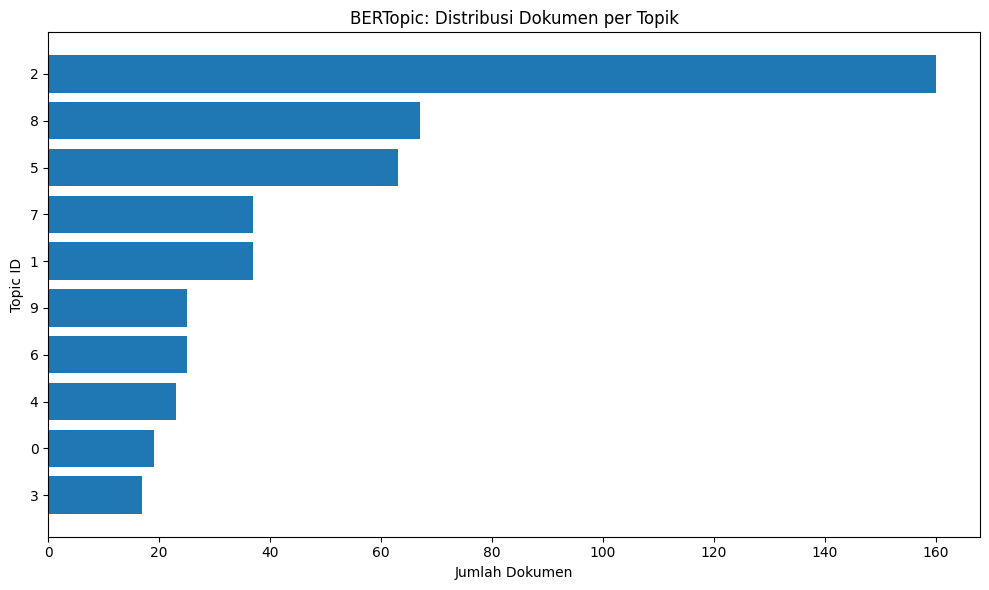

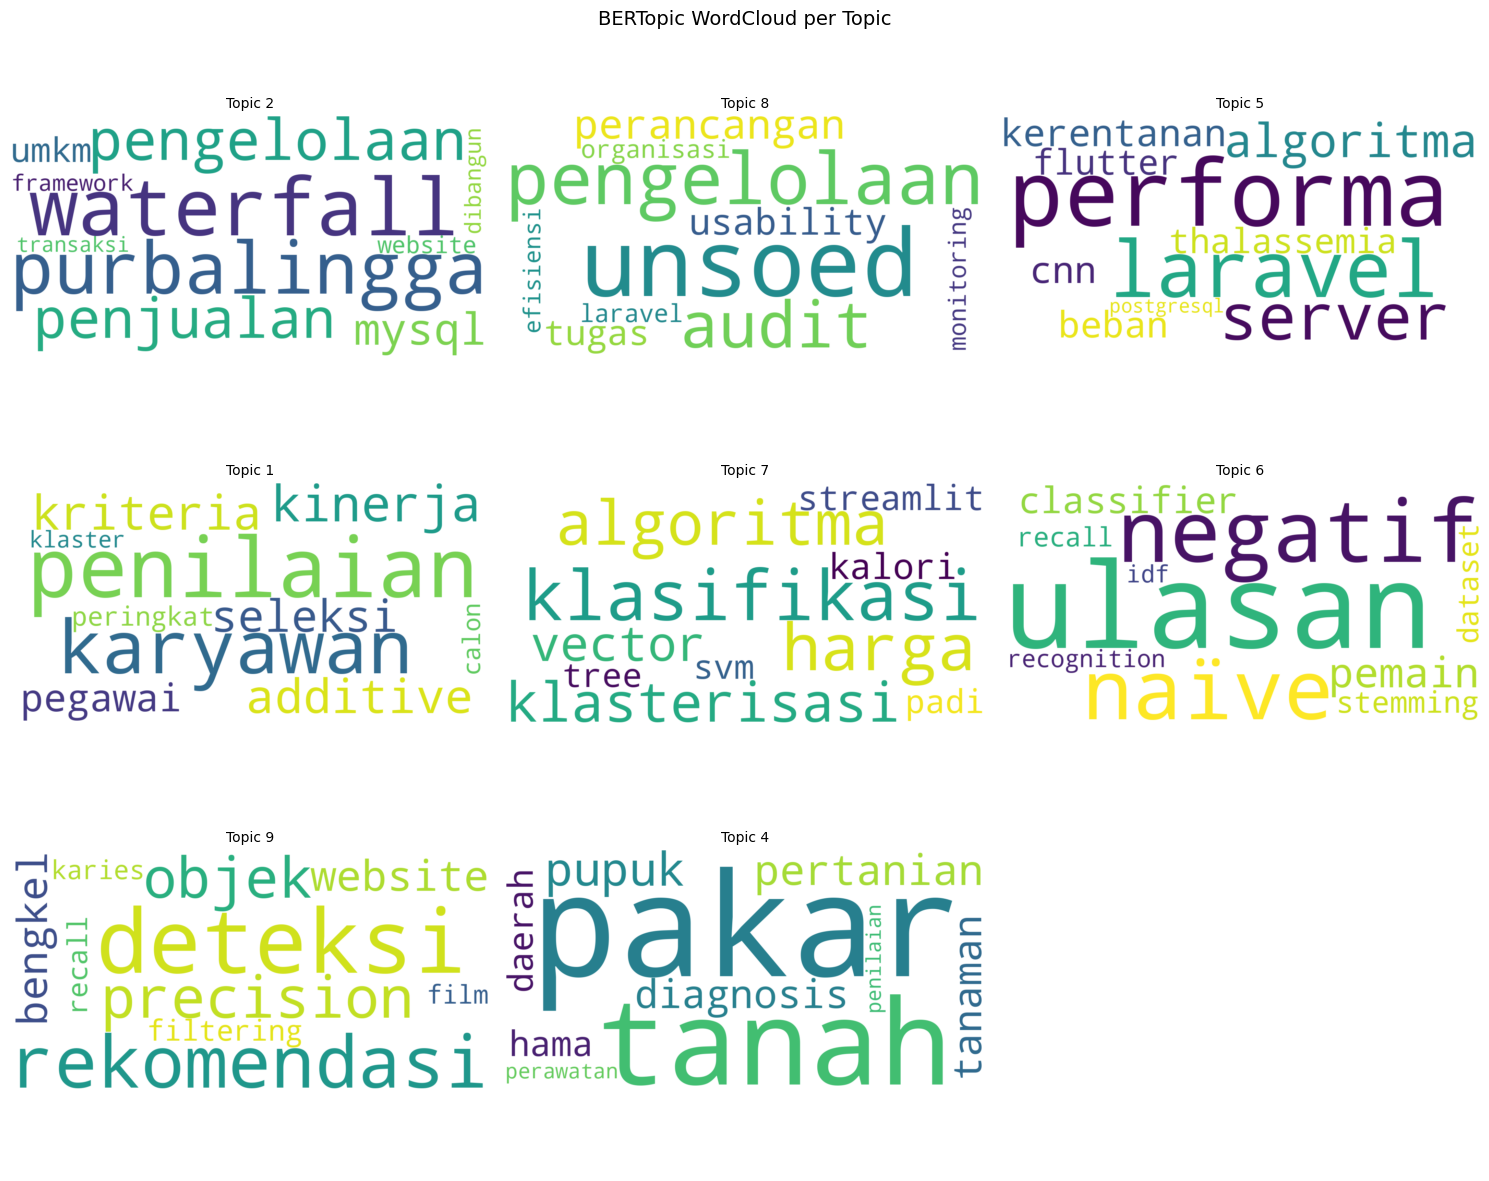


=== Visualisasi LDA ===


,topic_id,top_words
0,0,"barang, sakit, pakar, produk, jual, website, b..."
1,1,"informasi, nilai, desa, kelola, bangun, dasar,..."
2,2,"aplikasi, kembang, uji, proses, informasi, lar..."
3,3,"halaman, dasar, nilai, seleksi, uji, implement..."
4,4,"game, guna, uji, kembang, user, edukasi, tingk..."
5,5,"aplikasi, ajar, guna, dasar, bas, rekomendasi,..."
6,6,"model, nilai, prediksi, hasil, klasifikasi, ak..."
7,7,"informasi, bangun, bas, kelola, kembang, mudah..."


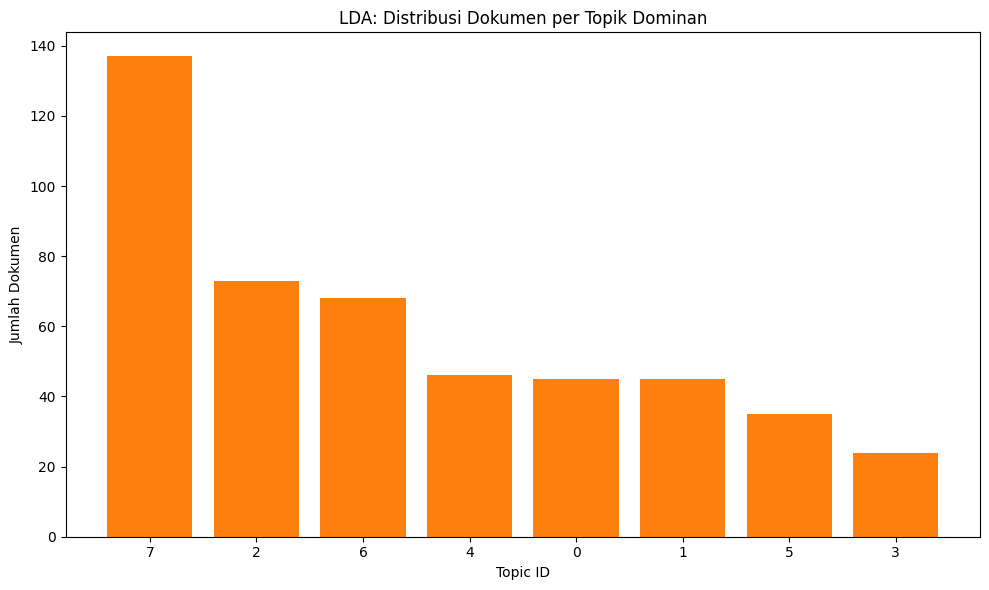

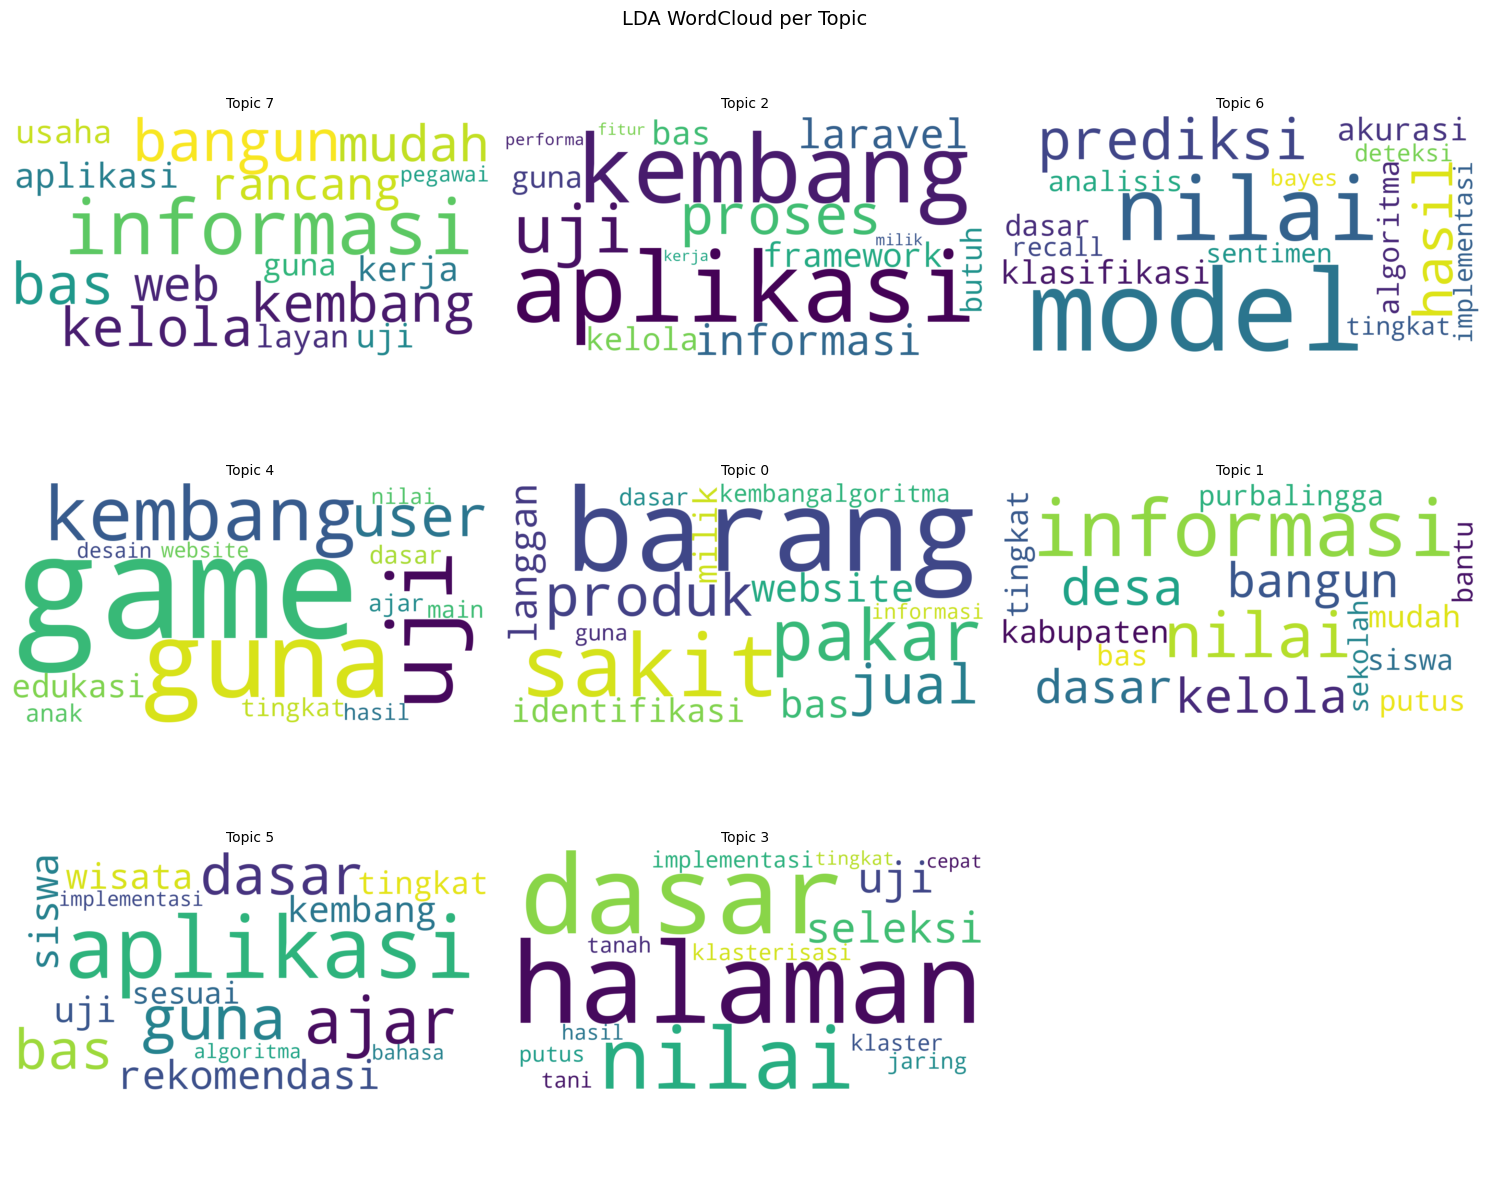


=== Perbandingan Metrics Best Model ===


,model,scenario_id,coherence_cv,topic_diversity,num_topics,model_path
0,BERTopic,bertopic_021,0.4563,0.92,10,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...
1,LDA,lda_012,0.3556,0.65,8,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...


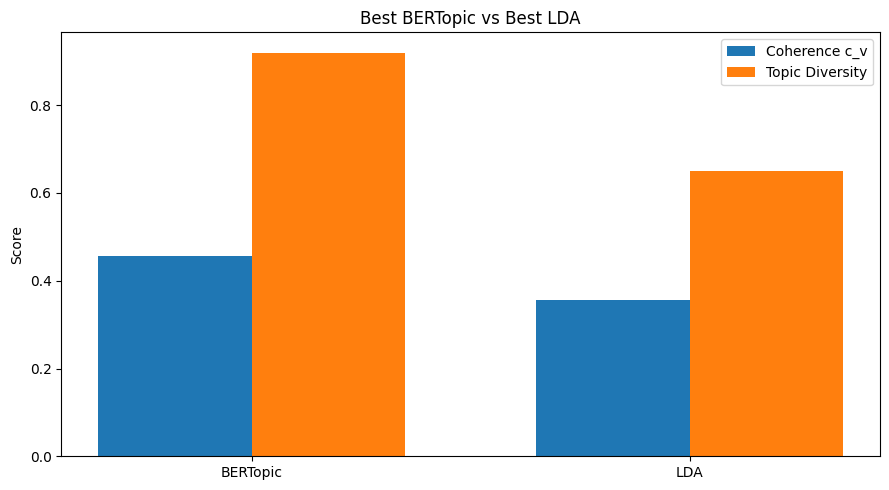


=== DTA BERTopic: Emerging / Stable / Declining ===


9it [05:45, 38.36s/it]


Ringkasan trend:


,trend_label,n_topics
0,declining,2
1,emerging,5
2,stable,3


,topic_id,trend_label,n_periods,start_frequency,end_frequency,slope,relative_slope,keywords_top10
0,4,declining,9,5.0,1.0,-0.183333,-0.071739,"pakar, tanah, pupuk, pertanian, diagnosis, tan..."
1,2,declining,9,26.0,2.0,-3.300000,-0.185625,"waterfall, purbalingga, pengelolaan, penjualan..."
2,0,emerging,5,1.0,8.0,1.900000,0.500000,"produk, clustering, penjualan, area, nasabah, ..."
3,5,emerging,9,3.0,5.0,1.900000,0.271429,"performa, laravel, server, algoritma, kerentan..."
4,7,emerging,8,1.0,6.0,1.202381,0.259974,"klasifikasi, harga, algoritma, klasterisasi, v..."
5,9,emerging,7,2.0,3.0,0.750000,0.210000,"deteksi, rekomendasi, precision, objek, websit..."
6,6,emerging,6,1.0,1.0,0.428571,0.102857,"ulasan, negatif, naïve, pemain, classifier, st..."
7,8,stable,9,7.0,4.0,0.300000,0.040299,"unsoed, pengelolaan, audit, perancangan, usabi..."
8,1,stable,8,6.0,1.0,0.130952,0.028314,"penilaian, karyawan, kinerja, kriteria, additi..."
9,3,stable,4,2.0,3.0,0.100000,0.023529,"edukasi, pembelajaran, anak, pengetahuan, leve..."


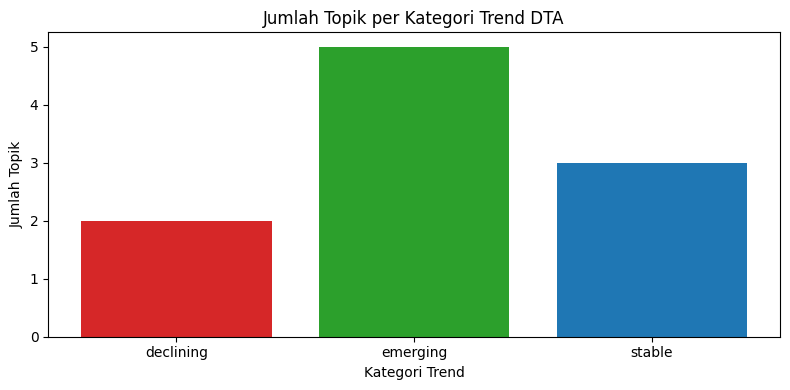

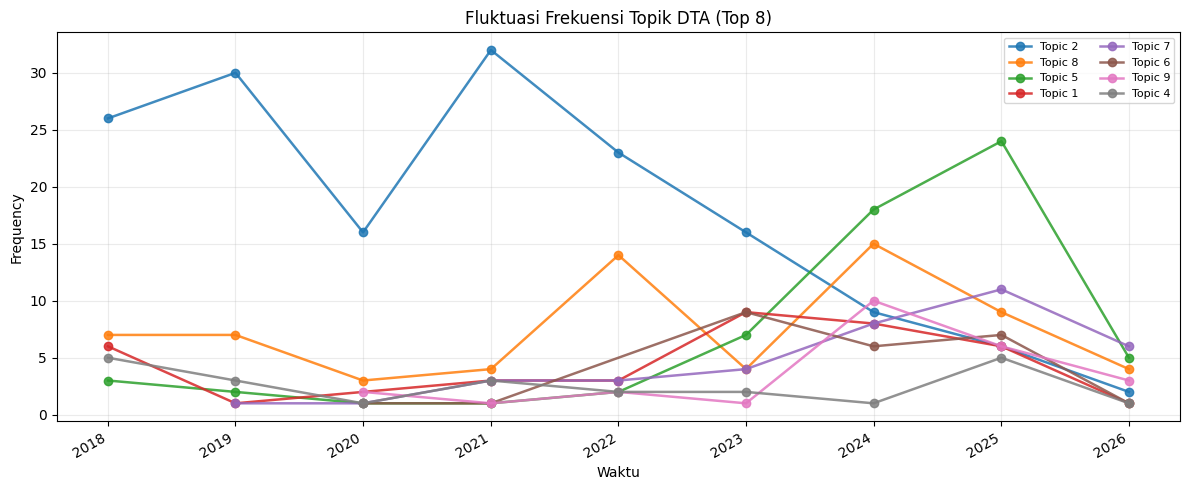

DTA artifacts:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001/dta_topics_over_time.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001/dta_topic_trend_classification.csv


In [15]:
def plot_wordcloud_grid(topic_payloads, title_text, max_topics=8, cols=3):
    if WordCloud is None:
        print(f"{title_text} dilewati: package wordcloud belum tersedia.")
        return
    payloads = [p for p in topic_payloads[:max_topics] if p.get("freq")]
    if not payloads:
        print(f"{title_text} dilewati: tidak ada topik valid.")
        return

    n = len(payloads)
    cols = max(1, min(cols, n))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, payload in zip(axes, payloads):
        wc = WordCloud(
            width=1400,
            height=700,
            background_color="white",
            colormap="viridis",
            max_words=200,
        ).generate_from_frequencies(payload["freq"])
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(payload.get("title", ""), fontsize=10)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title_text, fontsize=14)
    plt.tight_layout()
    plt.show()


print("=== Visualisasi BERTopic ===")
if final_bertopic is not None:
    b_model = final_bertopic["trainer"].model
    b_info = b_model.get_topic_info().copy()
    if "Topic" in b_info.columns:
        b_info = b_info[b_info["Topic"] != -1].copy()

    if not b_info.empty:
        cols_show = [c for c in ["Topic", "Count", "Name"] if c in b_info.columns]
        display(b_info[cols_show].head(15))

        if "Count" in b_info.columns:
            top_df = (
                b_info.sort_values("Count", ascending=False)
                .head(min(15, len(b_info)))
                .sort_values("Count")
            )
            plt.figure(figsize=(10, 6))
            plt.barh(top_df["Topic"].astype(str), top_df["Count"], color="#1f77b4")
            plt.title("BERTopic: Distribusi Dokumen per Topik")
            plt.xlabel("Jumlah Dokumen")
            plt.ylabel("Topic ID")
            plt.tight_layout()
            plt.show()

        wc_payloads = []
        if "Count" in b_info.columns:
            topic_ids = b_info.sort_values("Count", ascending=False)["Topic"].astype(int).head(8).tolist()
        else:
            topic_ids = b_info["Topic"].astype(int).head(8).tolist()

        for tid in topic_ids:
            words_scores = b_model.get_topic(int(tid)) or []
            freq = {w: float(s or 0.0) for w, s in words_scores[:15] if float(s or 0.0) > 0}
            wc_payloads.append({"title": f"Topic {int(tid)}", "freq": freq})

        plot_wordcloud_grid(wc_payloads, "BERTopic WordCloud per Topic", max_topics=8, cols=3)
    else:
        print("Topic info BERTopic kosong setelah filter outlier.")
else:
    print("Best BERTopic tidak tersedia.")

print("\n=== Visualisasi LDA ===")
if final_lda is not None:
    l_trainer = final_lda["trainer"]
    l_model = l_trainer.model

    lda_topic_rows = []
    for topic_id in range(l_model.num_topics):
        topic_words = l_model.show_topic(topic_id, topn=15)
        lda_topic_rows.append({
            "topic_id": int(topic_id),
            "top_words": ", ".join([w for w, _ in topic_words]),
        })

    lda_topic_df = pd.DataFrame(lda_topic_rows)
    display(lda_topic_df.head(15))

    lda_bows = [l_trainer.dictionary.doc2bow(str(doc).split()) for doc in lda_docs]
    dominant_topic_ids = []
    for bow in lda_bows:
        if not bow:
            continue
        dist = l_model.get_document_topics(bow, minimum_probability=0.0)
        if dist:
            dominant_topic_ids.append(int(max(dist, key=lambda x: x[1])[0]))

    topic_counts = Counter(dominant_topic_ids)
    if topic_counts:
        lda_count_df = pd.DataFrame({
            "topic_id": list(topic_counts.keys()),
            "doc_count": list(topic_counts.values()),
        }).sort_values("doc_count", ascending=False)

        plt.figure(figsize=(10, 6))
        plt.bar(
            lda_count_df["topic_id"].astype(str),
            lda_count_df["doc_count"],
            color="#ff7f0e",
        )
        plt.title("LDA: Distribusi Dokumen per Topik Dominan")
        plt.xlabel("Topic ID")
        plt.ylabel("Jumlah Dokumen")
        plt.tight_layout()
        plt.show()

        wc_topic_ids = lda_count_df["topic_id"].astype(int).head(8).tolist()
    else:
        wc_topic_ids = list(range(min(8, l_model.num_topics)))

    wc_payloads = []
    for tid in wc_topic_ids:
        words_scores = l_model.show_topic(int(tid), topn=15)
        freq = {w: float(s or 0.0) for w, s in words_scores if float(s or 0.0) > 0}
        wc_payloads.append({"title": f"Topic {int(tid)}", "freq": freq})

    plot_wordcloud_grid(wc_payloads, "LDA WordCloud per Topic", max_topics=8, cols=3)
else:
    print("Best LDA tidak tersedia.")

print("\n=== Perbandingan Metrics Best Model ===")
if not final_metrics_df.empty:
    display(final_metrics_df)
    metrics_plot_df = final_metrics_df.copy()
    for col in ["coherence_cv", "topic_diversity"]:
        metrics_plot_df[col] = pd.to_numeric(metrics_plot_df[col], errors="coerce")

    x = np.arange(len(metrics_plot_df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, metrics_plot_df["coherence_cv"], width=width, label="Coherence c_v")
    plt.bar(x + width / 2, metrics_plot_df["topic_diversity"], width=width, label="Topic Diversity")
    plt.xticks(x, metrics_plot_df["model"].tolist())
    plt.ylabel("Score")
    plt.title("Best BERTopic vs Best LDA")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Belum ada metrics best model.")


print("\n=== DTA BERTopic: Emerging / Stable / Declining ===")
dta_paths = []
if final_bertopic is None or timestamps is None:
    print("DTA dilewati: best BERTopic atau timestamps tidak tersedia.")
else:
    dta_model = final_bertopic["trainer"].model
    time_index = pd.to_datetime(pd.Series(timestamps).astype(int).astype(str) + "-01-01", errors="coerce")

    if time_index.isna().any():
        print("DTA dilewati: ada timestamp tidak valid.")
    else:
        try:
            dta_df = dta_model.topics_over_time(bertopic_docs, timestamps=time_index.tolist())
            if dta_df.empty:
                print("DTA menghasilkan dataframe kosong.")
            else:
                dta_df = dta_df.sort_values(["Topic", "Timestamp"]).reset_index(drop=True)
                dta_raw_path = RUN_DIR / "dta_topics_over_time.csv"
                dta_df.to_csv(dta_raw_path, index=False)
                dta_paths.append(dta_raw_path)

                trend_threshold = 0.03
                min_points = 3
                trend_rows = []

                work = dta_df.copy()
                work["Topic"] = pd.to_numeric(work["Topic"], errors="coerce")
                work = work[work["Topic"].notna()].copy()
                work["Topic"] = work["Topic"].astype(int)
                work = work[work["Topic"] != -1].copy()
                work["Frequency"] = pd.to_numeric(work["Frequency"], errors="coerce").fillna(0.0)

                for topic_id, g in work.groupby("Topic"):
                    g = g.sort_values("Timestamp")
                    y = g["Frequency"].to_numpy(dtype=float)
                    x = np.arange(len(g), dtype=float)
                    n_points = len(g)

                    if n_points < min_points:
                        trend_label = "insufficient_data"
                        slope = np.nan
                        relative_slope = np.nan
                    else:
                        slope = float(np.polyfit(x, y, 1)[0])
                        baseline = max(float(np.mean(y)), 1.0)
                        relative_slope = float(slope / baseline)

                        if relative_slope >= trend_threshold and float(y[-1]) >= float(y[0]):
                            trend_label = "emerging"
                        elif relative_slope <= -trend_threshold and float(y[-1]) <= float(y[0]):
                            trend_label = "declining"
                        else:
                            trend_label = "stable"

                    topic_words = dta_model.get_topic(int(topic_id)) or []
                    keywords = ", ".join([w for w, _ in topic_words[:10]])

                    trend_rows.append({
                        "topic_id": int(topic_id),
                        "trend_label": trend_label,
                        "n_periods": int(n_points),
                        "start_frequency": float(y[0]) if n_points else np.nan,
                        "end_frequency": float(y[-1]) if n_points else np.nan,
                        "slope": slope,
                        "relative_slope": relative_slope,
                        "keywords_top10": keywords,
                    })

                trend_df = pd.DataFrame(trend_rows)
                trend_df = trend_df.sort_values(["trend_label", "relative_slope"], ascending=[True, False], na_position="last").reset_index(drop=True)

                trend_path = RUN_DIR / "dta_topic_trend_classification.csv"
                trend_df.to_csv(trend_path, index=False)
                dta_paths.append(trend_path)

                print("Ringkasan trend:")
                summary_df = trend_df.groupby("trend_label", dropna=False).size().reset_index(name="n_topics")
                display(summary_df)
                display(trend_df)

                color_map = {
                    "emerging": "#2ca02c",
                    "stable": "#1f77b4",
                    "declining": "#d62728",
                    "insufficient_data": "#7f7f7f",
                }
                colors = [color_map.get(str(v), "#7f7f7f") for v in summary_df["trend_label"].astype(str)]
                plt.figure(figsize=(8, 4))
                plt.bar(summary_df["trend_label"].astype(str), summary_df["n_topics"], color=colors)
                plt.title("Jumlah Topik per Kategori Trend DTA")
                plt.xlabel("Kategori Trend")
                plt.ylabel("Jumlah Topik")
                plt.tight_layout()
                plt.show()

                top_topics = (
                    work.groupby("Topic", as_index=False)["Frequency"]
                    .sum()
                    .sort_values("Frequency", ascending=False)
                    .head(8)["Topic"]
                    .astype(int)
                    .tolist()
                )

                plt.figure(figsize=(12, 5))
                for tid in top_topics:
                    g = work[work["Topic"] == int(tid)].sort_values("Timestamp")
                    plt.plot(
                        pd.to_datetime(g["Timestamp"], errors="coerce"),
                        g["Frequency"],
                        marker="o",
                        linewidth=1.8,
                        alpha=0.85,
                        label=f"Topic {int(tid)}",
                    )
                plt.title("Fluktuasi Frekuensi Topik DTA (Top 8)")
                plt.xlabel("Waktu")
                plt.ylabel("Frequency")
                plt.xticks(rotation=30, ha="right")
                plt.grid(alpha=0.25)
                plt.legend(loc="best", ncol=2, fontsize=8)
                plt.tight_layout()
                plt.show()

        except Exception as exc:
            print("DTA gagal dijalankan:", exc)

if dta_paths:
    print("DTA artifacts:")
    for p in dta_paths:
        print("-", p)

In [16]:
artifact_rows = []
for p in sorted(RUN_DIR.glob("*")):
    if p.is_file():
        artifact_rows.append({
            "file": p.name,
            "size_kb": round(p.stat().st_size / 1024.0, 2),
        })

artifact_df = pd.DataFrame(artifact_rows).sort_values("file").reset_index(drop=True)
print("Artifact directory:", RUN_DIR)
display(artifact_df)

Artifact directory: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_web_form/run_20260419-191001


,file,size_kb
0,bertopic_loop_results.csv,25.15
1,bertopic_topic_keywords_long.csv,4.48
2,best_config.json,7.24
3,best_retrain_metrics.csv,0.44
4,dta_topic_trend_classification.csv,1.61
5,dta_topics_over_time.csv,4.71
6,lda_loop_results.csv,6.05
7,lda_topic_keywords_long.csv,4.67
8,model_comparison_leaderboard.csv,6.83
9,preprocess_step3_token_array_input_bertopic_ld...,2660.28
